# Fraud Detection - EDA on Merged Events Dataset

This notebook performs Exploratory Data Analysis on `merged_events.parquet`.

**Dataset Overview:**
- Event-level data: Each row represents a status change event for an insertion
- SEON features correlated to each event based on transaction timing
- Anonymized PII columns

**Goals:**
1. Understand data structure and quality
2. Analyze event distribution and lifecycle patterns
3. Explore fraud distribution (event-level and insertion-level)
4. Examine SEON features and their relationship to fraud
5. Compare SEON benchmark (seon_state) vs actual fraud labels

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Configure paths
DATA_PATH = "../artifacts/merged_events.parquet"

# Display settings
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(50)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load Data & Basic Info

In [2]:
print(f"Loading data from {DATA_PATH}...")
df = pl.read_parquet(DATA_PATH)

print(f"\n{'='*60}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"{'='*60}")

# Key identifiers - find the insertion ID column (may be hashed)
INSERTION_ID_COL = "INSERTION_ID_hash" if "INSERTION_ID_hash" in df.columns else "INSERTION_ID"
n_insertions = df.select(INSERTION_ID_COL).n_unique()
n_seon_txs = df.select("seon_tx_id").n_unique() if "seon_tx_id" in df.columns else "N/A"

print(f"\nUnique Insertions: {n_insertions:,}")
print(f"Unique SEON Transactions: {n_seon_txs}")
print(f"Avg Events per Insertion: {df.shape[0] / n_insertions:.2f}")

Loading data from ../artifacts/merged_events.parquet...

Shape: 732,589 rows x 230 columns

Unique Insertions: 86,160
Unique SEON Transactions: 124707
Avg Events per Insertion: 8.50


In [3]:
# Categorize columns by type
schema = df.schema

# Group columns by prefix/category
event_cols = [c for c in df.columns if c.upper() == c or c in [INSERTION_ID_COL, "seon_tx_id"]]
seon_cols = [c for c in df.columns if c not in event_cols]

# Further categorize SEON columns
score_cols = [c for c in seon_cols if "score" in c.lower()]
ip_cols = [c for c in seon_cols if c.startswith("ip") or "proxy" in c.lower()]
email_cols = [c for c in seon_cols if "email" in c.lower()]
phone_cols = [c for c in seon_cols if "phone" in c.lower()]
session_cols = [c for c in seon_cols if c.startswith("session")]

print("Column Categories:")
print(f"  Event columns: {len(event_cols)}")
print(f"  SEON columns: {len(seon_cols)}")
print(f"    - Score columns: {len(score_cols)}")
print(f"    - IP columns: {len(ip_cols)}")
print(f"    - Email columns: {len(email_cols)}")
print(f"    - Phone columns: {len(phone_cols)}")
print(f"    - Session columns: {len(session_cols)}")

print(f"\nScore columns: {score_cols}")

Column Categories:
  Event columns: 177
  SEON columns: 53
    - Score columns: 5
    - IP columns: 7
    - Email columns: 9
    - Phone columns: 9
    - Session columns: 5

Score columns: ['fraud_score', 'blackbox_score', 'phone_score', 'email_score', 'proxy_score']


In [4]:
# Display schema grouped by type
print("\nSchema Overview (first 30 columns):")
for i, (col, dtype) in enumerate(list(schema.items())[:30]):
    print(f"  {col:50s} -> {dtype}")
print(f"  ... and {len(schema) - 30} more columns")


Schema Overview (first 30 columns):
  AGENCYID                                           -> String
  AUTOAPPROVALCRITERIA_CRITERIA_HASUSEDSAMEEMAILBEFORE -> Boolean
  AUTOAPPROVALCRITERIA_CRITERIA_SEONAPPROVED         -> Boolean
  AUTOAPPROVALCRITERIA_META_SEONFRAUDSCORE           -> Float64
  ARCHIVALREASON_KEY                                 -> String
  ARCHIVALREASON_REASON                              -> String
  CONTACTREQUESTDATE                                 -> String
  CUSTOMERSEGMENT                                    -> String
  FIRSTPUBLISHEDDATE                                 -> String
  FLAGGEDFORFAKECHECK                                -> Boolean
  FLAGGEDFORFRAUD                                    -> String
  FURTHESTPAGE                                       -> String
  LASTPUBLISHEDVERSION                               -> String
  LASTMIGRATED                                       -> String
  LISTINGID                                          -> Int64
  LISTING_DEL

## 2. Data Quality & Coverage

In [5]:
# Check null rates for key columns
total_rows = df.height

# Focus on important columns
key_cols = [
    INSERTION_ID_COL, "TIME", "STATUS", "is_fraud", "seon_tx_id",
    "seon_state", "fraud_score", "blackbox_score", "email_score", "phone_score"
]
key_cols = [c for c in key_cols if c in df.columns]

coverage_data = []
for col in key_cols:
    null_count = df[col].null_count()
    coverage = (1 - null_count / total_rows) * 100
    coverage_data.append({
        "column": col,
        "dtype": str(schema.get(col, "N/A")),
        "nulls": null_count,
        "coverage_pct": round(coverage, 2)
    })

coverage_df = pl.DataFrame(coverage_data).sort("coverage_pct")
print("Key Column Coverage:")
print(coverage_df)

Key Column Coverage:
shape: (10, 4)
┌───────────────────┬─────────┬────────┬──────────────┐
│ column            ┆ dtype   ┆ nulls  ┆ coverage_pct │
│ ---               ┆ ---     ┆ ---    ┆ ---          │
│ str               ┆ str     ┆ i64    ┆ f64          │
╞═══════════════════╪═════════╪════════╪══════════════╡
│ phone_score       ┆ Float64 ┆ 201820 ┆ 72.45        │
│ blackbox_score    ┆ Float64 ┆ 45     ┆ 99.99        │
│ INSERTION_ID_hash ┆ String  ┆ 0      ┆ 100.0        │
│ TIME              ┆ String  ┆ 0      ┆ 100.0        │
│ STATUS            ┆ String  ┆ 0      ┆ 100.0        │
│ is_fraud          ┆ Int8    ┆ 0      ┆ 100.0        │
│ seon_tx_id        ┆ Int64   ┆ 0      ┆ 100.0        │
│ seon_state        ┆ String  ┆ 0      ┆ 100.0        │
│ fraud_score       ┆ Float64 ┆ 0      ┆ 100.0        │
│ email_score       ┆ Int64   ┆ 3      ┆ 100.0        │
└───────────────────┴─────────┴────────┴──────────────┘


In [6]:
# Overall column coverage analysis
coverage_stats = []
for col in df.columns:
    null_count = df[col].null_count()
    coverage = (1 - null_count / total_rows) * 100
    coverage_stats.append({"column": col, "coverage_pct": coverage})

coverage_all = pl.DataFrame(coverage_stats)

# Distribution of coverage
print("Coverage Distribution:")
print(f"  100% coverage: {coverage_all.filter(pl.col('coverage_pct') == 100).height} columns")
print(f"  90-100%: {coverage_all.filter((pl.col('coverage_pct') >= 90) & (pl.col('coverage_pct') < 100)).height} columns")
print(f"  50-90%: {coverage_all.filter((pl.col('coverage_pct') >= 50) & (pl.col('coverage_pct') < 90)).height} columns")
print(f"  <50%: {coverage_all.filter(pl.col('coverage_pct') < 50).height} columns")

# Lowest coverage columns
print("\nLowest Coverage Columns (bottom 10):")
print(coverage_all.sort("coverage_pct").head(10))

Coverage Distribution:
  100% coverage: 52 columns
  90-100%: 43 columns
  50-90%: 25 columns
  <50%: 110 columns

Lowest Coverage Columns (bottom 10):
shape: (10, 2)
┌──────────────────────────────────────────────────┬──────────────┐
│ column                                           ┆ coverage_pct │
│ ---                                              ┆ ---          │
│ str                                              ┆ f64          │
╞══════════════════════════════════════════════════╪══════════════╡
│ LISTING_CHARACTERISTICS_HASCONNECTEDBUILDINGLAND ┆ 0.001092     │
│ LISTING_LISTER_CONTACTS_VIEWING_EMAIL_hash       ┆ 0.001365     │
│ LISTING_LISTER_CONTACTS_INQUIRY_FAMILYNAME_hash  ┆ 0.001638     │
│ LISTING_LISTER_LOGOURL                           ┆ 0.002321     │
│ LISTING_LISTER_ADDRESS_REGION                    ┆ 0.002321     │
│ LISTING_CHARACTERISTICS_CRANECAPACITY            ┆ 0.00273      │
│ LISTING_LISTER_BILLING_COUPONID                  ┆ 0.003549     │
│ LISTING_DELETED

## 3. Event Status Distribution

Event Status Distribution:
shape: (9, 3)
┌────────────────────────────┬────────┬───────┐
│ STATUS                     ┆ len    ┆ pct   │
│ ---                        ┆ ---    ┆ ---   │
│ str                        ┆ u32    ┆ f64   │
╞════════════════════════════╪════════╪═══════╡
│ PENDING_APPROVAL           ┆ 172056 ┆ 23.49 │
│ PUBLISHED                  ┆ 143680 ┆ 19.61 │
│ ARCHIVED                   ┆ 115455 ┆ 15.76 │
│ APPROVED                   ┆ 78701  ┆ 10.74 │
│ ARCHIVING                  ┆ 76872  ┆ 10.49 │
│ REPUBLISHING               ┆ 69016  ┆ 9.42  │
│ PENDING_REPUBLISH_APPROVAL ┆ 48081  ┆ 6.56  │
│ DELETED                    ┆ 22751  ┆ 3.11  │
│ CONTACT_REQUESTED          ┆ 5977   ┆ 0.82  │
└────────────────────────────┴────────┴───────┘


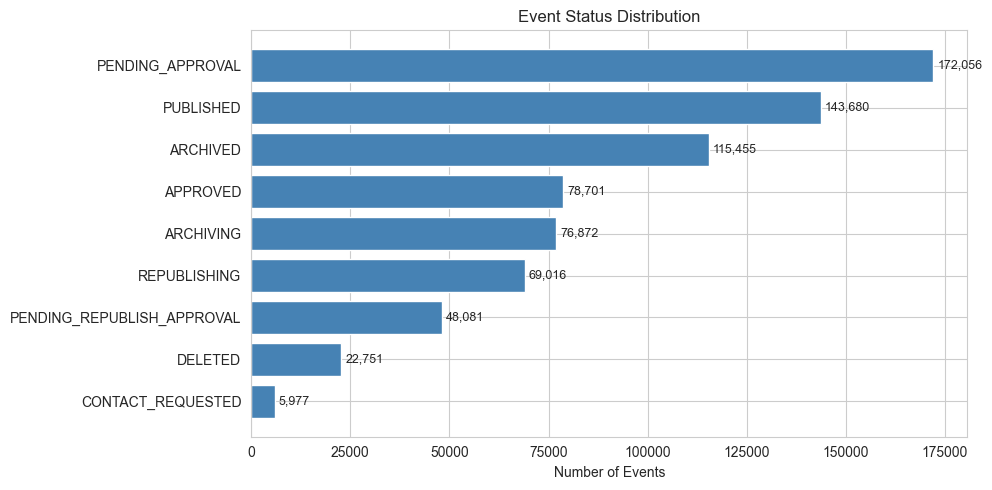

In [7]:
# Status distribution
status_col = "STATUS"
if status_col in df.columns:
    status_dist = (
        df.group_by(status_col)
        .len()
        .sort("len", descending=True)
        .with_columns(
            (pl.col("len") / total_rows * 100).round(2).alias("pct")
        )
    )
    print("Event Status Distribution:")
    print(status_dist)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 5))
    statuses = status_dist[status_col].to_list()
    counts = status_dist["len"].to_list()
    
    bars = ax.barh(statuses[::-1], counts[::-1], color="steelblue")
    ax.set_xlabel("Number of Events")
    ax.set_title("Event Status Distribution")
    
    # Add count labels
    for bar, count in zip(bars, counts[::-1]):
        ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2, 
                f"{count:,}", va="center", fontsize=9)
    
    plt.tight_layout()
    plt.show()

Events per Insertion Statistics:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 86160.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 8.502658 │
│ std        ┆ 2.600559 │
│ min        ┆ 2.0      │
│ 25%        ┆ 7.0      │
│ 50%        ┆ 8.0      │
│ 75%        ┆ 11.0     │
│ max        ┆ 15.0     │
└────────────┴──────────┘


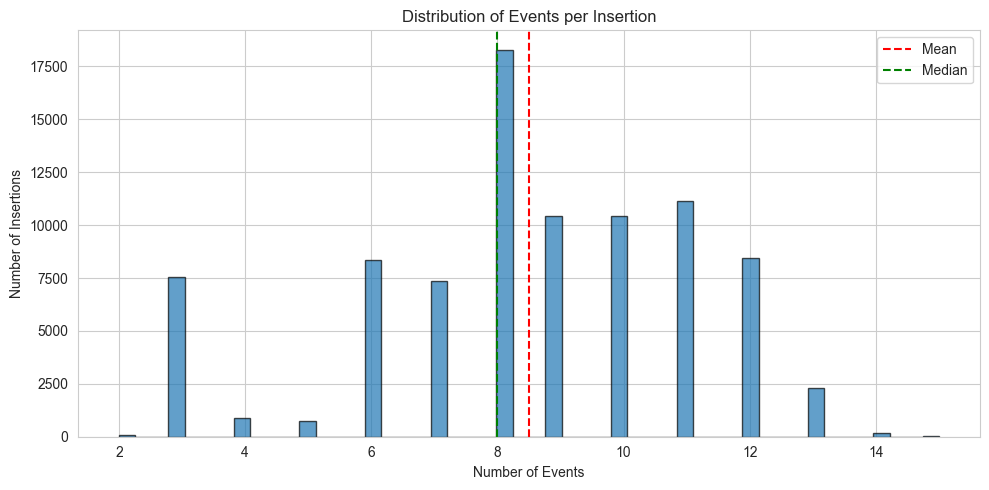

In [8]:
# Events per insertion distribution
events_per_insertion = (
    df.group_by(INSERTION_ID_COL)
    .len()
    .rename({"len": "n_events"})
)

print("Events per Insertion Statistics:")
print(events_per_insertion["n_events"].describe())

# Histogram
fig, ax = plt.subplots(figsize=(10, 5))
event_counts = events_per_insertion["n_events"].to_list()
ax.hist(event_counts, bins=50, edgecolor="black", alpha=0.7)
ax.set_xlabel("Number of Events")
ax.set_ylabel("Number of Insertions")
ax.set_title("Distribution of Events per Insertion")
ax.axvline(x=events_per_insertion["n_events"].mean(), color="red", linestyle="--", label="Mean")
ax.axvline(x=events_per_insertion["n_events"].median(), color="green", linestyle="--", label="Median")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Fraud Distribution

In [9]:
# Event-level fraud distribution
target_col = "is_fraud"

if target_col in df.columns:
    fraud_dist = df[target_col].value_counts().sort(target_col)
    print("Event-Level Fraud Distribution:")
    print(fraud_dist)
    
    fraud_rate_event = df[target_col].mean() * 100
    print(f"\nEvent-level Fraud Rate: {fraud_rate_event:.2f}%")
else:
    print(f"Target column '{target_col}' not found.")

Event-Level Fraud Distribution:
shape: (2, 2)
┌──────────┬────────┐
│ is_fraud ┆ count  │
│ ---      ┆ ---    │
│ i8       ┆ u32    │
╞══════════╪════════╡
│ 0        ┆ 725604 │
│ 1        ┆ 6985   │
└──────────┴────────┘

Event-level Fraud Rate: 0.95%


Insertion-Level Fraud Distribution:
shape: (2, 2)
┌────────────────────┬───────┐
│ is_fraud_insertion ┆ count │
│ ---                ┆ ---   │
│ i8                 ┆ u32   │
╞════════════════════╪═══════╡
│ 0                  ┆ 79175 │
│ 1                  ┆ 6985  │
└────────────────────┴───────┘

Insertion-level Fraud Rate: 8.11%


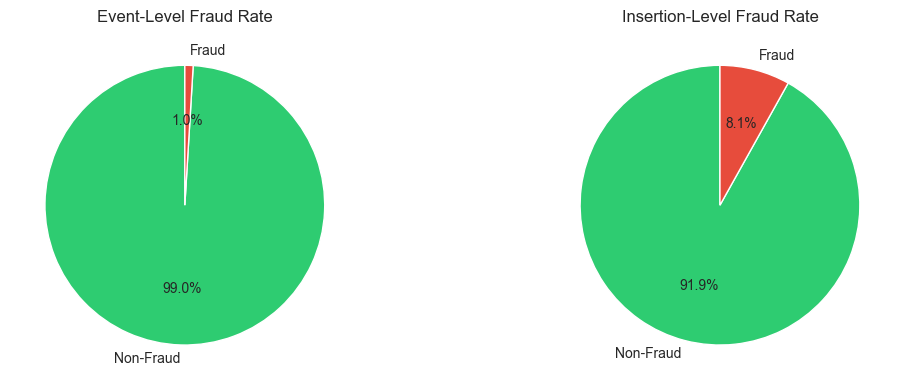

In [10]:
# Insertion-level fraud: An insertion is fraud if ANY of its events is fraud
insertion_fraud = (
    df.group_by(INSERTION_ID_COL)
    .agg(pl.col("is_fraud").max().alias("is_fraud_insertion"))
)

insertion_fraud_dist = insertion_fraud["is_fraud_insertion"].value_counts().sort("is_fraud_insertion")
print("Insertion-Level Fraud Distribution:")
print(insertion_fraud_dist)

fraud_rate_insertion = insertion_fraud["is_fraud_insertion"].mean() * 100
print(f"\nInsertion-level Fraud Rate: {fraud_rate_insertion:.2f}%")

# Comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Event-level
ax1 = axes[0]
labels = ["Non-Fraud", "Fraud"]
sizes = [100 - fraud_rate_event, fraud_rate_event]
colors = ["#2ecc71", "#e74c3c"]
ax1.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
ax1.set_title("Event-Level Fraud Rate")

# Insertion-level
ax2 = axes[1]
sizes = [100 - fraud_rate_insertion, fraud_rate_insertion]
ax2.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
ax2.set_title("Insertion-Level Fraud Rate")

plt.tight_layout()
plt.show()

In [11]:
# Fraud by status
fraud_by_status = (
    df.group_by("STATUS")
    .agg([
        pl.len().alias("total"),
        pl.col("is_fraud").sum().alias("fraud_count"),
        pl.col("is_fraud").mean().alias("fraud_rate")
    ])
    .sort("fraud_rate", descending=True)
    .with_columns(
        (pl.col("fraud_rate") * 100).round(2).alias("fraud_rate_pct")
    )
)

print("Fraud Rate by Status:")
print(fraud_by_status)

Fraud Rate by Status:
shape: (9, 5)
┌────────────────────────────┬────────┬─────────────┬────────────┬────────────────┐
│ STATUS                     ┆ total  ┆ fraud_count ┆ fraud_rate ┆ fraud_rate_pct │
│ ---                        ┆ ---    ┆ ---         ┆ ---        ┆ ---            │
│ str                        ┆ u32    ┆ i64         ┆ f64        ┆ f64            │
╞════════════════════════════╪════════╪═════════════╪════════════╪════════════════╡
│ DELETED                    ┆ 22751  ┆ 4826        ┆ 0.212123   ┆ 21.21          │
│ ARCHIVING                  ┆ 76872  ┆ 2159        ┆ 0.028086   ┆ 2.81           │
│ PUBLISHED                  ┆ 143680 ┆ 0           ┆ 0.0        ┆ 0.0            │
│ APPROVED                   ┆ 78701  ┆ 0           ┆ 0.0        ┆ 0.0            │
│ ARCHIVED                   ┆ 115455 ┆ 0           ┆ 0.0        ┆ 0.0            │
│ PENDING_REPUBLISH_APPROVAL ┆ 48081  ┆ 0           ┆ 0.0        ┆ 0.0            │
│ CONTACT_REQUESTED          ┆ 5977   ┆ 

## 5. SEON Features Analysis (Benchmark Reference)

> **Note:** SEON scores are shown for understanding the benchmark. They are **NOT** used as model features.

SEON Score Statistics:
shape: (9, 6)
┌────────────┬─────────────┬────────────────┬─────────────┬─────────────┬─────────────┐
│ statistic  ┆ fraud_score ┆ blackbox_score ┆ email_score ┆ phone_score ┆ proxy_score │
│ ---        ┆ ---         ┆ ---            ┆ ---         ┆ ---         ┆ ---         │
│ str        ┆ f64         ┆ f64            ┆ f64         ┆ f64         ┆ f64         │
╞════════════╪═════════════╪════════════════╪═════════════╪═════════════╪═════════════╡
│ count      ┆ 732589.0    ┆ 732544.0       ┆ 732586.0    ┆ 530769.0    ┆ 732589.0    │
│ null_count ┆ 0.0         ┆ 45.0           ┆ 3.0         ┆ 201820.0    ┆ 0.0         │
│ mean       ┆ 7.176912    ┆ 18.523822      ┆ 1.863103    ┆ 0.200287    ┆ 1.312187    │
│ std        ┆ 16.246074   ┆ 24.893704      ┆ 4.931626    ┆ 0.40753     ┆ 3.039261    │
│ min        ┆ 0.0         ┆ 0.0            ┆ 0.0         ┆ 0.0         ┆ 0.0         │
│ 25%        ┆ 0.0         ┆ 0.41           ┆ 0.0         ┆ 0.0         ┆ 0.0      

/var/folders/4m/g11mmd5d45592_f6ntg98gr80000gn/T/ipykernel_10111/288786503.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="is_fraud", y=col, ax=ax, palette=["#2ecc71", "#e74c3c"])
/var/folders/4m/g11mmd5d45592_f6ntg98gr80000gn/T/ipykernel_10111/288786503.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])
/var/folders/4m/g11mmd5d45592_f6ntg98gr80000gn/T/ipykernel_10111/288786503.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="is_fraud", y=col, ax=ax, palette=["#2ecc71", "#e74c3c"])
/var/folders/4m/g11mmd5d45592_f6ntg98gr80000gn/T

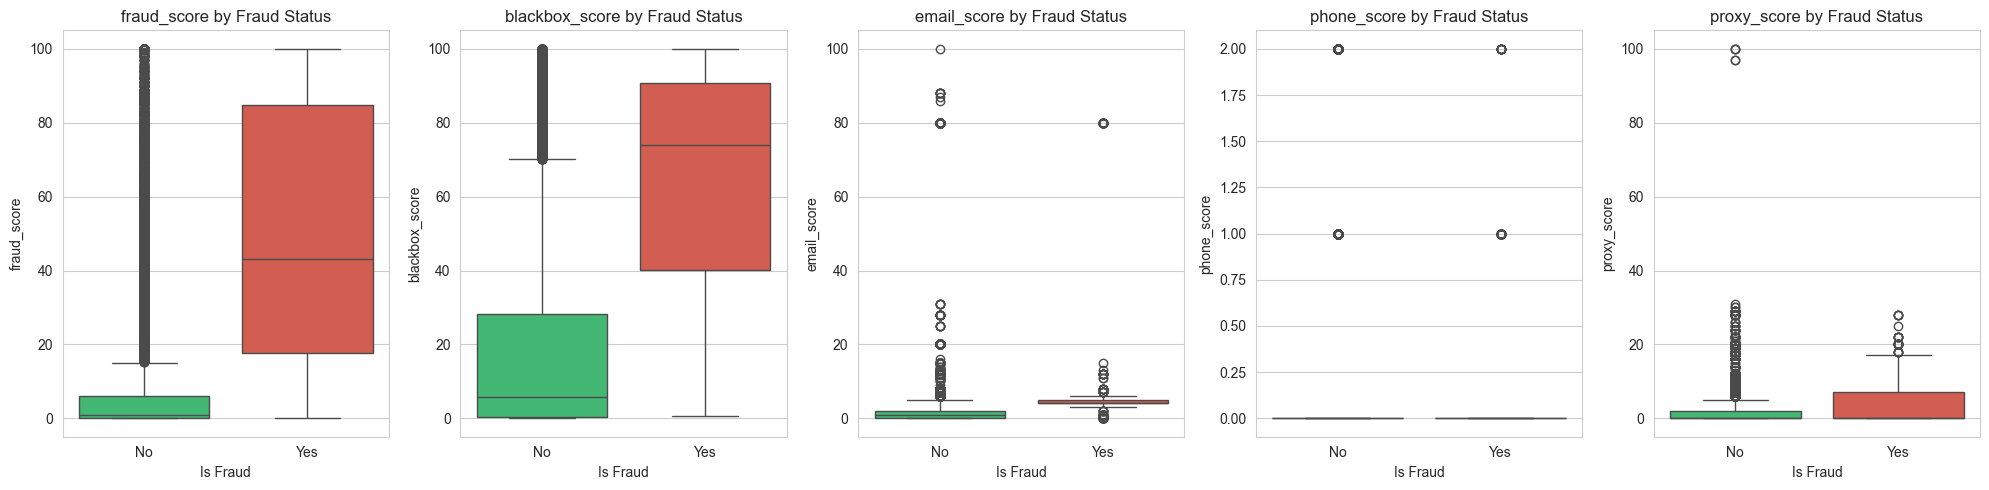

In [12]:
# SEON score distributions
score_cols_available = [c for c in ["fraud_score", "blackbox_score", "email_score", "phone_score", "proxy_score"] if c in df.columns]

if score_cols_available:
    print("SEON Score Statistics:")
    score_stats = df.select(score_cols_available).describe()
    print(score_stats)
    
    # Box plots by fraud status
    fig, axes = plt.subplots(1, len(score_cols_available), figsize=(4*len(score_cols_available), 5))
    if len(score_cols_available) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, score_cols_available):
        # Sample for plotting if too large
        plot_df = df.select([col, "is_fraud"]).drop_nulls().sample(min(50000, df.height), seed=42).to_pandas()
        
        sns.boxplot(data=plot_df, x="is_fraud", y=col, ax=ax, palette=["#2ecc71", "#e74c3c"])
        ax.set_xlabel("Is Fraud")
        ax.set_ylabel(col)
        ax.set_title(f"{col} by Fraud Status")
        ax.set_xticklabels(["No", "Yes"])
    
    plt.tight_layout()
    plt.show()
else:
    print("No SEON score columns found.")

In [13]:
# SEON state (benchmark) distribution
benchmark_col = "seon_state"
if benchmark_col in df.columns:
    state_dist = (
        df.group_by(benchmark_col)
        .agg([
            pl.len().alias("count"),
            pl.col("is_fraud").mean().alias("actual_fraud_rate")
        ])
        .sort("count", descending=True)
        .with_columns(
            (pl.col("actual_fraud_rate") * 100).round(2).alias("fraud_rate_pct")
        )
    )
    
    print(f"SEON State (Benchmark) Distribution:")
    print(state_dist)

SEON State (Benchmark) Distribution:
shape: (3, 4)
┌────────────┬────────┬───────────────────┬────────────────┐
│ seon_state ┆ count  ┆ actual_fraud_rate ┆ fraud_rate_pct │
│ ---        ┆ ---    ┆ ---               ┆ ---            │
│ str        ┆ u32    ┆ f64               ┆ f64            │
╞════════════╪════════╪═══════════════════╪════════════════╡
│ APPROVE    ┆ 632440 ┆ 0.000057          ┆ 0.01           │
│ REVIEW     ┆ 66301  ┆ 0.000211          ┆ 0.02           │
│ DECLINE    ┆ 33848  ┆ 0.204887          ┆ 20.49          │
└────────────┴────────┴───────────────────┴────────────────┘


In [14]:
# Benchmark vs Actual: Confusion matrix style analysis
if benchmark_col in df.columns:
    # Map SEON state to prediction (DECLINE/BLOCK = fraud, APPROVE = not fraud)
    df_benchmark = df.with_columns(
        pl.when(pl.col(benchmark_col).is_in(["DECLINE", "BLOCK", "MANUAL_REVIEW"]))
        .then(1)
        .otherwise(0)
        .alias("seon_predicted_fraud")
    )
    
    confusion = (
        df_benchmark.group_by(["seon_predicted_fraud", "is_fraud"])
        .len()
        .sort(["seon_predicted_fraud", "is_fraud"])
    )
    
    print("\nSEON Prediction vs Actual Fraud:")
    print(confusion)
    
    # Calculate metrics
    tn = df_benchmark.filter((pl.col("seon_predicted_fraud") == 0) & (pl.col("is_fraud") == 0)).height
    fp = df_benchmark.filter((pl.col("seon_predicted_fraud") == 1) & (pl.col("is_fraud") == 0)).height
    fn = df_benchmark.filter((pl.col("seon_predicted_fraud") == 0) & (pl.col("is_fraud") == 1)).height
    tp = df_benchmark.filter((pl.col("seon_predicted_fraud") == 1) & (pl.col("is_fraud") == 1)).height
    
    print(f"\nConfusion Matrix:")
    print(f"  TN: {tn:,}  FP: {fp:,}")
    print(f"  FN: {fn:,}  TP: {tp:,}")
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\nSEON Benchmark Performance:")
    print(f"  Precision: {precision:.2%}")
    print(f"  Recall: {recall:.2%}")
    print(f"  F1 Score: {f1:.2%}")


SEON Prediction vs Actual Fraud:
shape: (4, 3)
┌──────────────────────┬──────────┬────────┐
│ seon_predicted_fraud ┆ is_fraud ┆ len    │
│ ---                  ┆ ---      ┆ ---    │
│ i32                  ┆ i8       ┆ u32    │
╞══════════════════════╪══════════╪════════╡
│ 0                    ┆ 0        ┆ 698691 │
│ 0                    ┆ 1        ┆ 50     │
│ 1                    ┆ 0        ┆ 26913  │
│ 1                    ┆ 1        ┆ 6935   │
└──────────────────────┴──────────┴────────┘

Confusion Matrix:
  TN: 698,691  FP: 26,913
  FN: 50  TP: 6,935

SEON Benchmark Performance:
  Precision: 20.49%
  Recall: 99.28%
  F1 Score: 33.97%


## 6. Temporal Analysis

In [15]:
# Parse TIME column if string
time_col = "TIME"
if time_col in df.columns:
    # Check if already datetime
    if df.schema[time_col] == pl.Utf8:
        df = df.with_columns(
            pl.col(time_col)
            .str.replace(" Z", "+00:00")
            .str.to_datetime(format=None, time_zone="UTC", strict=False)
            .alias("event_datetime")
        )
    else:
        df = df.with_columns(pl.col(time_col).alias("event_datetime"))
    
    # Time range
    min_date = df["event_datetime"].min()
    max_date = df["event_datetime"].max()
    print(f"Time Range: {min_date} to {max_date}")

Time Range: 2024-10-01 00:09:06.040000+00:00 to 2025-12-15 15:00:37.358000+00:00


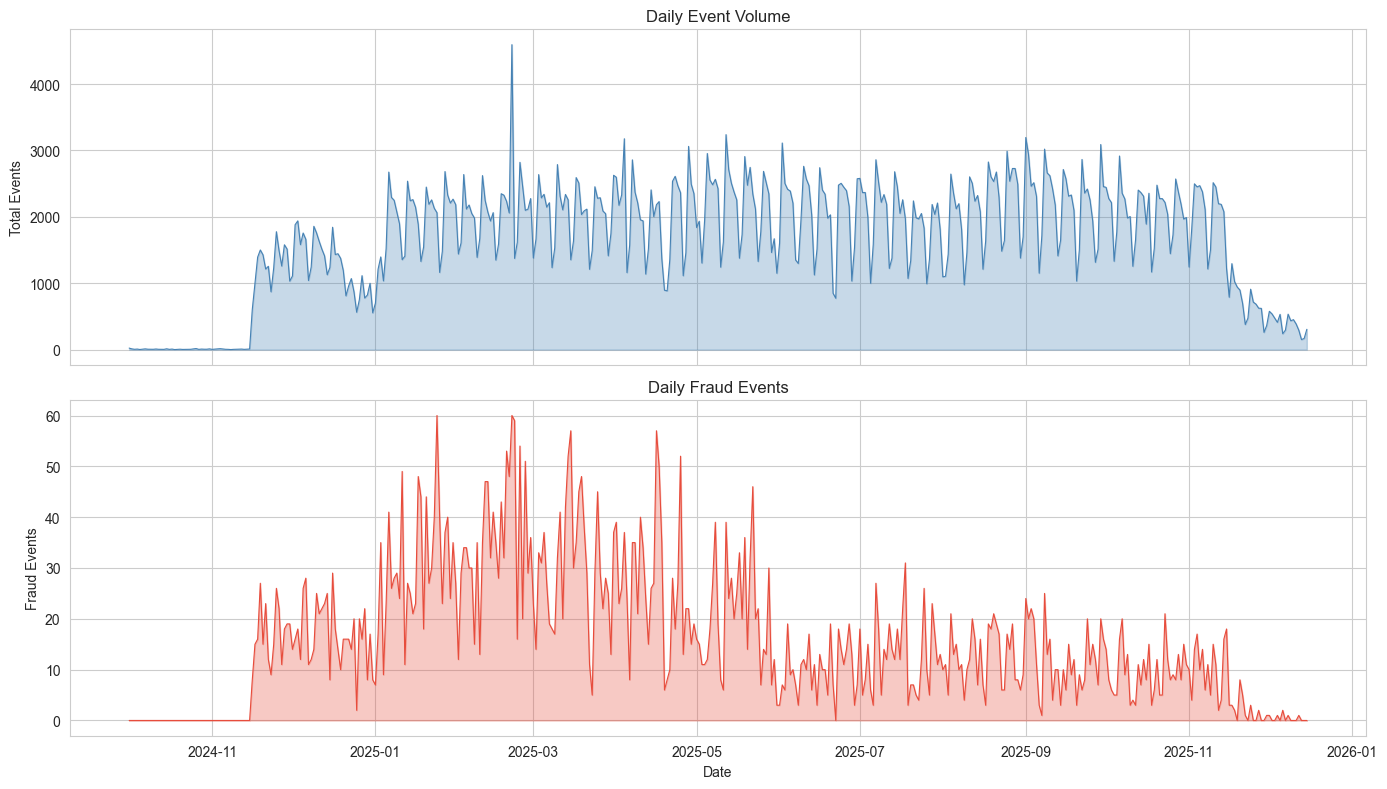

In [16]:
# Daily event volume
if "event_datetime" in df.columns:
    daily_events = (
        df.filter(pl.col("event_datetime").is_not_null())
        .with_columns(pl.col("event_datetime").dt.date().alias("date"))
        .group_by("date")
        .agg([
            pl.len().alias("events"),
            pl.col("is_fraud").sum().alias("fraud_events")
        ])
        .sort("date")
    )
    
    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    dates = daily_events["date"].to_list()
    events = daily_events["events"].to_list()
    fraud = daily_events["fraud_events"].to_list()
    
    axes[0].plot(dates, events, color="steelblue", linewidth=0.8)
    axes[0].fill_between(dates, events, alpha=0.3, color="steelblue")
    axes[0].set_ylabel("Total Events")
    axes[0].set_title("Daily Event Volume")
    
    axes[1].plot(dates, fraud, color="#e74c3c", linewidth=0.8)
    axes[1].fill_between(dates, fraud, alpha=0.3, color="#e74c3c")
    axes[1].set_ylabel("Fraud Events")
    axes[1].set_xlabel("Date")
    axes[1].set_title("Daily Fraud Events")
    
    plt.tight_layout()
    plt.show()

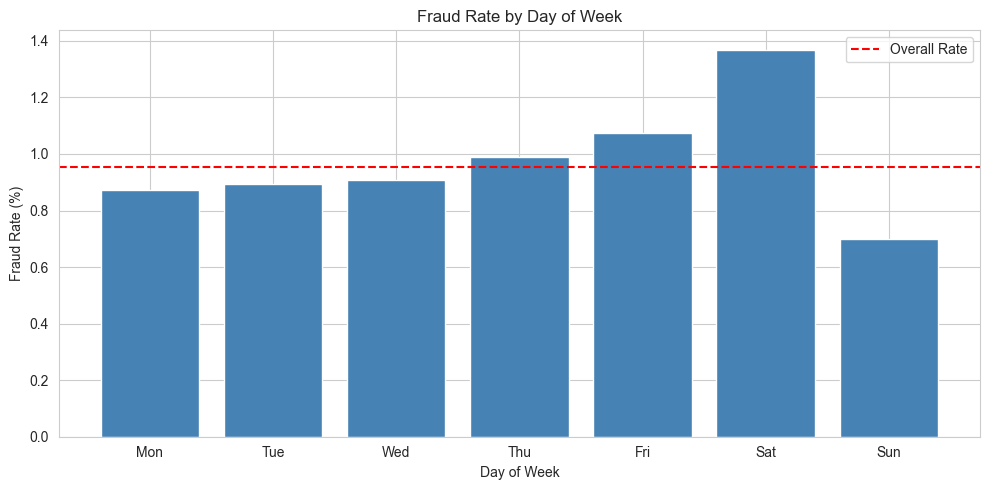

In [17]:
# Fraud rate by day of week
if "event_datetime" in df.columns:
    dow_fraud = (
        df.filter(pl.col("event_datetime").is_not_null())
        .with_columns(pl.col("event_datetime").dt.weekday().alias("day_of_week"))
        .group_by("day_of_week")
        .agg([
            pl.len().alias("total"),
            pl.col("is_fraud").mean().alias("fraud_rate")
        ])
        .sort("day_of_week")
    )
    
    day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    fraud_rates = [r * 100 for r in dow_fraud["fraud_rate"].to_list()]
    ax.bar(day_names, fraud_rates, color="steelblue")
    ax.set_xlabel("Day of Week")
    ax.set_ylabel("Fraud Rate (%)")
    ax.set_title("Fraud Rate by Day of Week")
    ax.axhline(y=fraud_rate_event, color="red", linestyle="--", label="Overall Rate")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 7. Summary Statistics

In [18]:
# Final summary
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"\nData Shape:")
print(f"  Total Events: {df.height:,}")
print(f"  Total Columns: {len(df.columns)}")
print(f"  Unique Insertions: {n_insertions:,}")

print(f"\nFraud Statistics:")
print(f"  Event-level fraud rate: {fraud_rate_event:.2f}%")
print(f"  Insertion-level fraud rate: {fraud_rate_insertion:.2f}%")

if "event_datetime" in df.columns:
    print(f"\nTime Range:")
    print(f"  From: {min_date}")
    print(f"  To: {max_date}")

print(f"\nColumn Categories:")
print(f"  Event columns: {len(event_cols)}")
print(f"  SEON feature columns: {len(seon_cols)}")
print("="*60)

DATASET SUMMARY

Data Shape:
  Total Events: 732,589
  Total Columns: 231
  Unique Insertions: 86,160

Fraud Statistics:
  Event-level fraud rate: 0.95%
  Insertion-level fraud rate: 8.11%

Time Range:
  From: 2024-10-01 00:09:06.040000+00:00
  To: 2025-12-15 15:00:37.358000+00:00

Column Categories:
  Event columns: 177
  SEON feature columns: 53
